<a href="https://colab.research.google.com/github/ge25anshika-hue/Time_Series_Analysis/blob/main/Time_series_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

stock_data = yf.download('AAPL', start='2025-01-01')
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.301926,247.518596,240.284814,247.349662,55740700
2025-01-03,241.815018,242.629804,240.354349,241.815018,40244100
2025-01-06,243.444611,245.759820,241.656035,242.758989,45045600
2025-01-07,240.672348,243.991141,239.817807,241.437449,40856000
2025-01-08,241.159225,242.162823,238.526055,240.384178,37628900


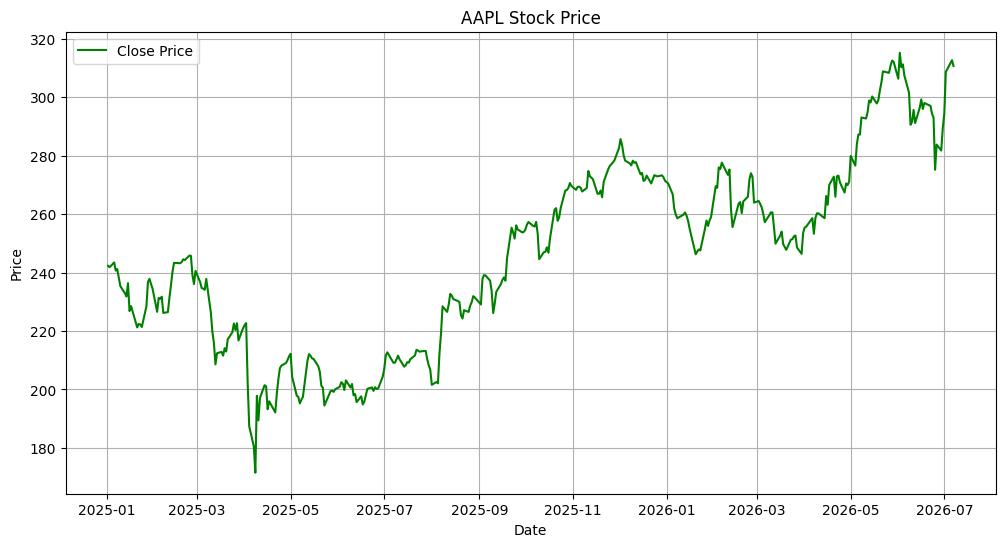

In [2]:
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price',color='green' )
plt.title('AAPL Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Classical Time series decomposition

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition_additive= seasonal_decompose(stock_data['Close'],model='additive', period = 30)


In [4]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid


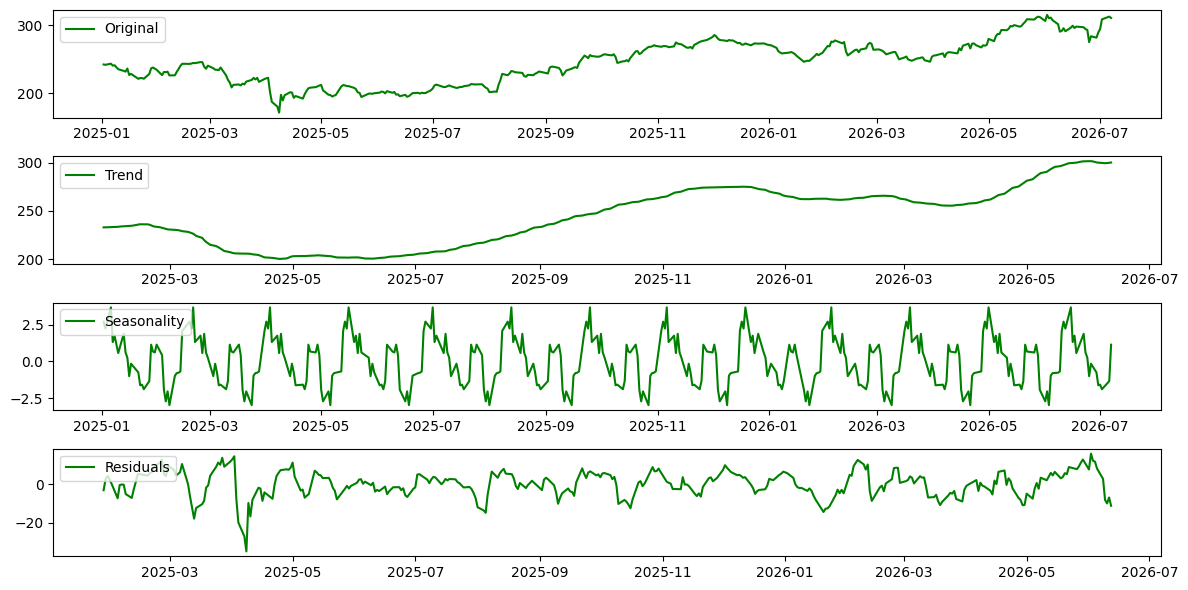

In [5]:
plt.figure(figsize=(12, 6))
plt.subplot(411)
plt.plot(stock_data.index, stock_data['Close'], label='Original', color = 'green')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(stock_data.index, trend_additive, label='Trend',color = 'green')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(stock_data.index, seasonal_additive,label='Seasonality',color = 'green')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(stock_data.index, residual_additive, label='Residuals',color = 'green')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

STL Decomposition

In [6]:
from statsmodels.tsa.seasonal import STL



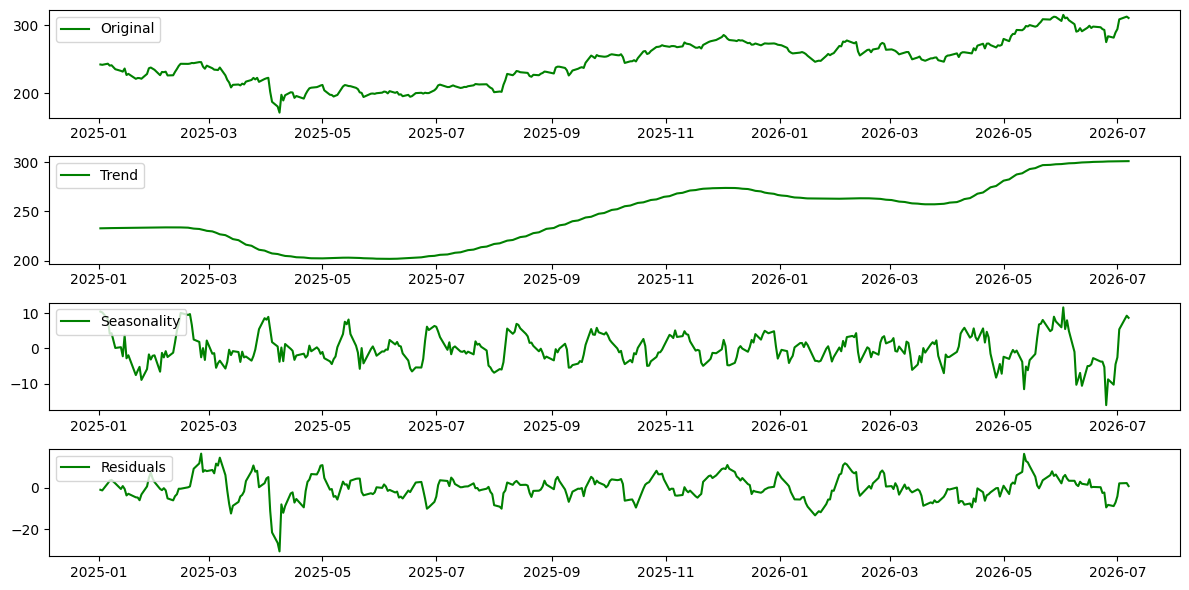

In [7]:
stl = STL(stock_data['Close'], period = 30)
res = stl.fit()
plt.figure(figsize=(12, 6))
plt.subplot(411)
plt.plot(stock_data.index, stock_data['Close'], label='Original', color = 'green')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(stock_data.index, res.trend, label='Trend',color = 'green')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(stock_data.index, res.seasonal,label='Seasonality',color = 'green')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(stock_data.index, res.resid, label='Residuals',color = 'green')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Weak Stationarity test - ADF , KPSS

In [8]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(stock_data['Close'])
print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')
print(f'Critical Values:')
for key, value in adf_test[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -0.6353982334180335
p-value: 0.8627812195083921
Critical Values:
   1%: -3.4480516066132636
   5%: -2.869340997473759
   10%: -2.5709257824604


In [9]:
from statsmodels.tsa.stattools import kpss
kpss_test = kpss(stock_data['Close'])
print(f'KPSS Statistic: {kpss_test[0]}')
print(f'p-value: {kpss_test[1]}')
print(f'Critical Values:')
for key, value in kpss_test[3].items():
    print(f'   {key}: {value}')

KPSS Statistic: 2.3822280354394048
p-value: 0.01
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


/tmp/ipykernel_1776/704258159.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(stock_data['Close'])


ADF - null hypothesis = non stationarity
      alternate hypothesis = stationarity
      if  P value < 0.05, null rejected
      here, 0.8 so non stationry data
KPSS - null hypo= stationary
       alternate hypo= non stationary
       if P-value< 0.05 then, null rejected
       here 0.01 , so non stationary

  Therefore, both tests show that the data is non stationary



Strict Stationarity test

<Figure size 1200x600 with 0 Axes>

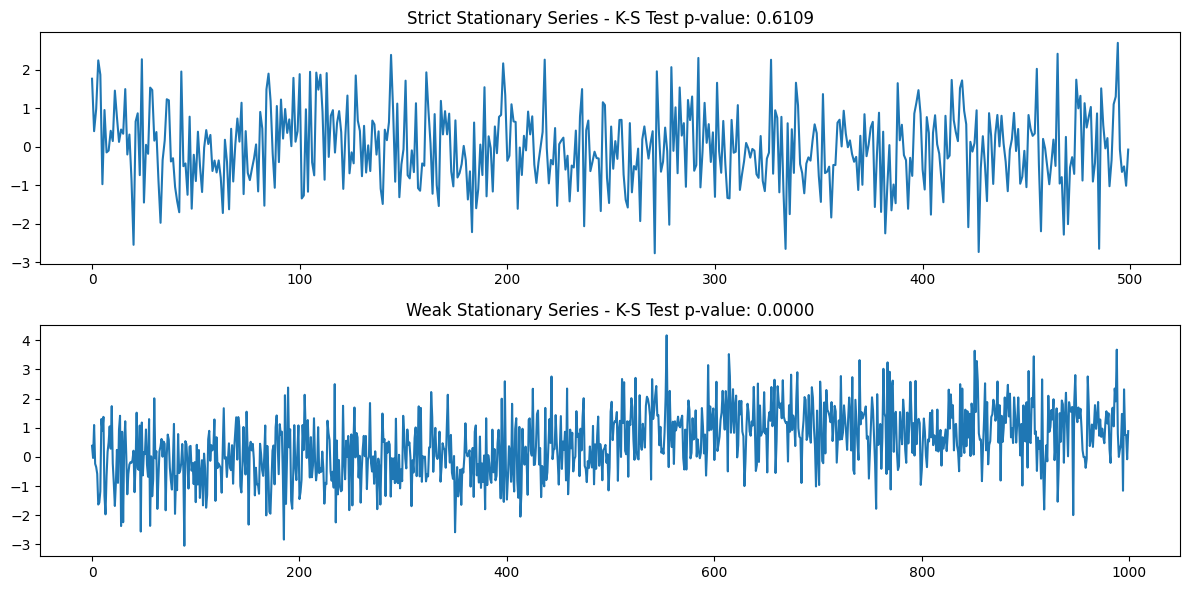

Strict Stationary Series - K-S Test Statistic: 0.068, p-value: 0.6109
Weak Stationary Series - K-S Test Statistic: 0.462, p-value: 0.0000


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
np.random.seed(0)
n= 500
strict_stationary_series = np.random.normal(loc=0, scale=1, size=n)
non_strict_stationary_data = np.concatenate([
    np.random.normal(loc=0, scale=1, size=n),
    np.random.normal(loc=1, scale=1, size=n)
])
def ks_test_stationarity(series):
  split = len(series) // 2
  series_1 = series[:split]
  series_2 = series[split:]
  stat, p_value = ks_2samp(series[:split], series[split:])
  return stat, p_value

ks_stat_strict, p_value_strict = ks_test_stationarity(strict_stationary_series)
ks_stat_non_strict, p_value_non_strict = ks_test_stationarity(non_strict_stationary_data)
plt.figure(figsize=(12, 6))
ks_stat_non_strict, p_value_non_strict = ks_test_stationarity(non_strict_stationary_data)

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(strict_stationary_series)
plt.title(f"Strict Stationary Series - K-S Test p-value: {p_value_strict:.4f}")

plt.subplot(2,1,2)
plt.plot(non_strict_stationary_data)
plt.title(f"Weak Stationary Series - K-S Test p-value: {p_value_non_strict:.4f}")

plt.tight_layout()
plt.show()

print(f"Strict Stationary Series - K-S Test Statistic: {ks_stat_strict:.3f}, p-value: {p_value_strict:.4f}")
print(f"Weak Stationary Series - K-S Test Statistic: {ks_stat_non_strict:.3f}, p-value: {p_value_non_strict:.4f}")




null = stationary
alternate = non-stationary
here P-value = 0.6>0.05, so accept null, hence it holds strict stationarity  also means, no difference in data overall


White noise and Random walk

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [12]:
np.random.seed(0)
n= 1000

In [13]:
white_noise = np.random.normal(loc=0, scale=1, size=n)
random_shocks = np.random.normal(loc=0, scale=1, size=n)
random_walk = np.cumsum(np.random.normal(loc=0, scale=1, size=n))


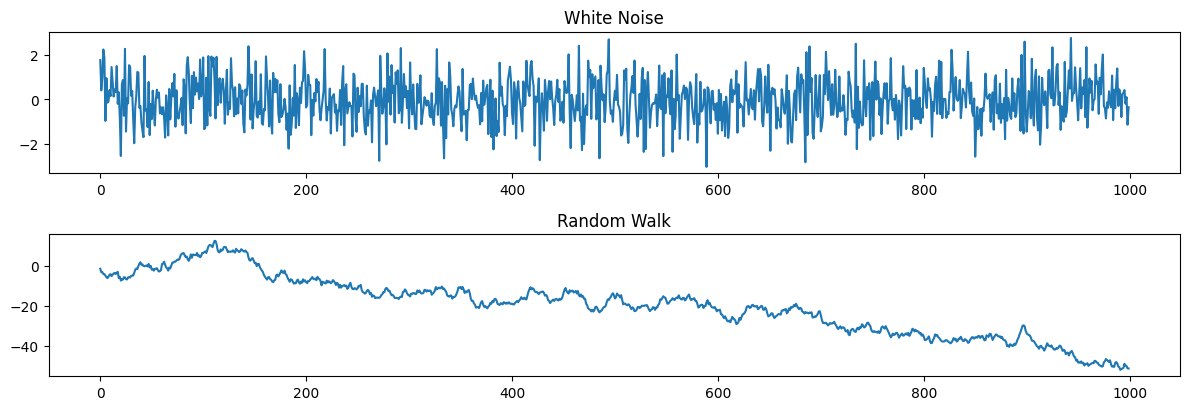


Ljung-Box Test for White Noise:
      lb_stat  lb_pvalue
10  14.025574   0.171828

Ljung-Box Test for Random Walk:
        lb_stat  lb_pvalue
10  9510.565455        0.0


In [14]:
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(white_noise)
plt.title('White Noise')
plt.subplot(3, 1, 2)

plt.plot(random_walk)
plt.title('Random Walk')
plt.tight_layout()
plt.show()

#Ljung box-test
print("\nLjung-Box Test for White Noise:")
lb_test_white_noise = acorr_ljungbox(white_noise, lags=[10], return_df=True)
print(lb_test_white_noise)

print("\nLjung-Box Test for Random Walk:")
lb_test_random_walk= acorr_ljungbox(random_walk, lags=[10], return_df= True)
print(lb_test_random_walk)


null = no auto
alternate= auto, P value< 0.05 , 0.17, so reject null


Making the Data Stationary

**AR MODEL**

In [15]:
stock_data = yf.download('AAPL', start='2025-01-01')
apple_price_stationary = stock_data['Close'].diff().dropna()
train_data , test_data = apple_price_stationary[:-30], apple_price_stationary[-30:]


[*********************100%***********************]  1 of 1 completed


train-test split and took last 30 days as test data, and applied differencing, drop na if any values are na

In [16]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(apple_price_stationary)
print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')
print(f'Critical Values:')
for key, value in adf_test[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -10.150238943044535
p-value: 7.986578475267076e-18
Critical Values:
   1%: -3.4480516066132636
   5%: -2.869340997473759
   10%: -2.5709257824604


checked the converted data and, as p value is close to 0 , so null rejected, hence sttaionary - ADF Test
similarly p value= 0.1> 0.05 for KPSS test, hence stationary

In [17]:
from statsmodels.tsa.stattools import kpss
kpss_test = kpss(apple_price_stationary)
print(f'KPSS Statistic: {kpss_test[0]}')
print(f'p-value: {kpss_test[1]}')
print(f'Critical Values:')
for key, value in kpss_test[3].items():
    print(f'   {key}: {value}')

KPSS Statistic: 0.16064389626816689
p-value: 0.1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


/tmp/ipykernel_1776/173904250.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(apple_price_stationary)


Model Performance

In [18]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [19]:
model = AutoReg(train_data, lags=30)
model_fit = model.fit()
predictions = model_fit.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, dynamic = False)

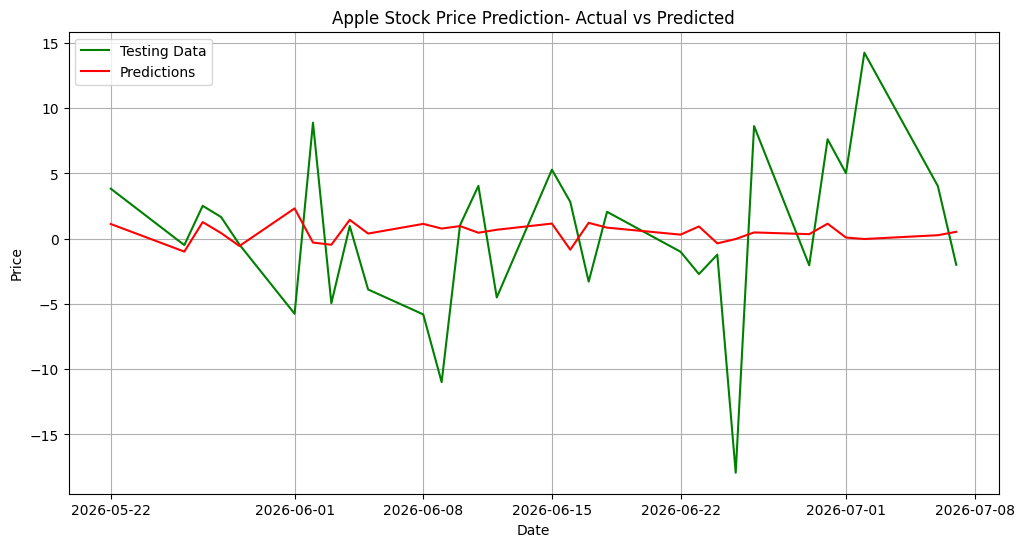

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_data, label='Testing Data', color='green')
plt.plot(test_data.index, predictions, label='Predictions', color='red')
plt.title('Apple Stock Price Prediction- Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

evaluating model using RMSE score


In [21]:
rmse= round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

RMSE:  6.26


huge forecasting differences and a high rmse score means the actual model is 6.26 units away from the predictions

similarly MA, ARMA models

**ARIMA MODEL**

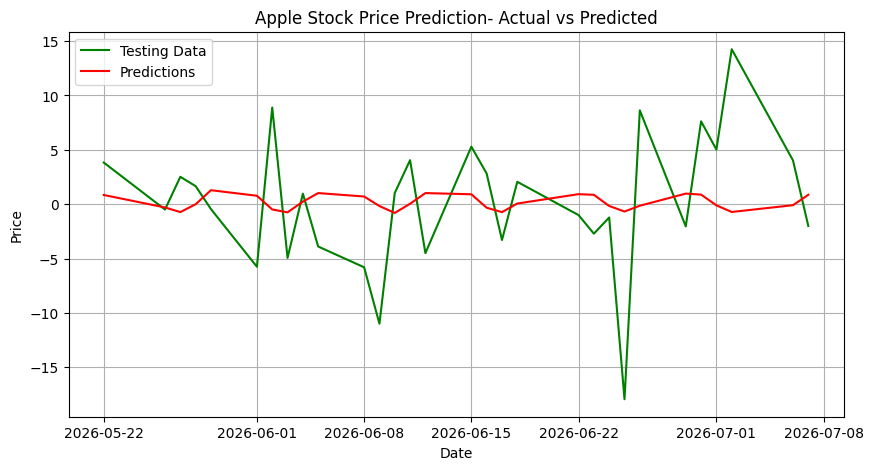

RMSE:  6.24


In [22]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data, order= (7,1,7))
model_fit = model.fit()
predictions = model_fit.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, dynamic = False)

plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label='Testing Data', color='green')
plt.plot(test_data.index, predictions, label='Predictions', color='red')
plt.title('Apple Stock Price Prediction- Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

rmse= round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)
